<a href="https://colab.research.google.com/github/14marcos1/ELT578/blob/main/relatorio578001ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

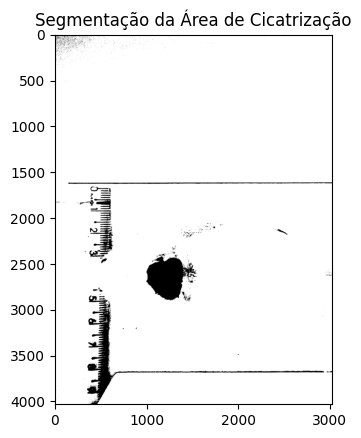

In [7]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# 1. Carregar a imagem da ferida
img = cv2.imread('ferida_animal.JPG')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Exemplo de segmentação simples por cor (ajuste conforme necessário)
# Isso ajudará a calcular a área da ferida para os seus "Resultados"
lower_red = np.array([100, 50, 50])
upper_red = np.array([255, 255, 255])
mask = cv2.inRange(img_rgb, lower_red, upper_red)

plt.imshow(mask, cmap='gray')
plt.title('Segmentação da Área de Cicatrização')
plt.show()

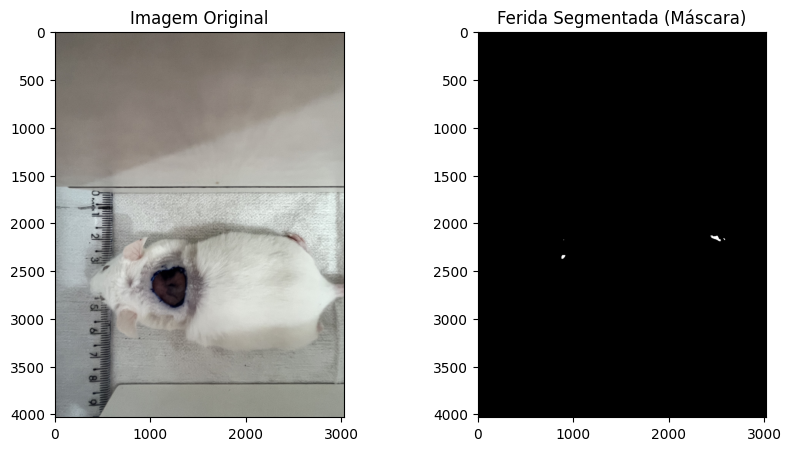

Área total da ferida em pixels: 4541


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregamento e Conversão
img = cv2.imread('ferida_animal.JPG')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# 2. Segmentação (Ajuste os limites conforme suas fotos)
# Tons de vermelho/carne para a ferida
lower_red = np.array([0, 50, 50])
upper_red = np.array([10, 255, 255])
mask = cv2.inRange(img_hsv, lower_red, upper_red)

# 3. Limpeza de Ruído (Morfologia)
kernel = np.ones((5,5), np.uint8)
opening = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# 4. Cálculo da Área em Pixels
area_pixels = np.sum(opening == 255)

# Exibição dos Resultados para o Relatório
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagem Original')
plt.imshow(img_rgb)
plt.subplot(1, 2, 2)
plt.title('Ferida Segmentada (Máscara)')
plt.imshow(opening, cmap='gray')
plt.show()

print(f"Área total da ferida em pixels: {area_pixels}")

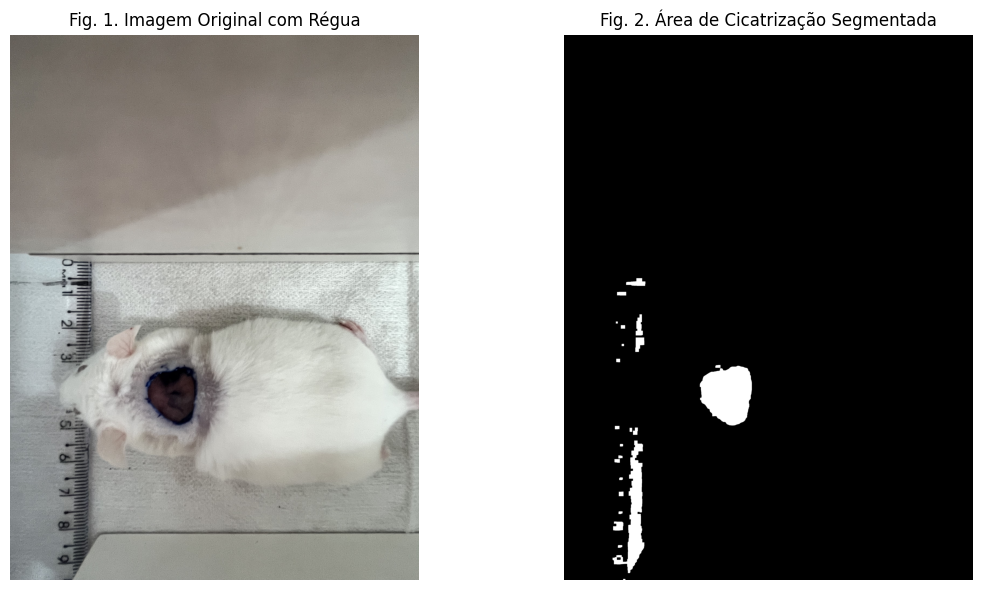

Resultados da Análise:
Área em pixels: 242178
Área estimada: 8.90 cm²


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Carregamento
img = cv2.imread('ferida_animal.JPG')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2. Pré-processamento: Filtro para suavizar o pelo e destacar a ferida
blur = cv2.GaussianBlur(gray, (7, 7), 0)

# 3. Limiarização (Thresholding) - Ajustado para tons escuros
# O valor '70' pode ser ajustado dependendo da iluminação da foto
_, mask = cv2.threshold(blur, 70, 255, cv2.THRESH_BINARY_INV)

# 4. Limpeza Morfológica (Remove ruídos da régua e pelos)
kernel = np.ones((15,15), np.uint8)
closing = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel) # Fecha buracos internos
opening = cv2.morphologyEx(closing, cv2.MORPH_OPEN, kernel) # Remove pontos pequenos fora

# 5. Calibração (Referência da Régua)
# Olhando sua foto, 1cm na régua parece ter aprox. 165 pixels (ajuste conforme necessário)
pixels_por_cm = 165
area_pixels = np.sum(opening == 255)
area_cm2 = area_pixels / (pixels_por_cm**2)

# Exibição seguindo as recomendações do template IEEE
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Fig. 1. Imagem Original com Régua') # [cite: 68]
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Fig. 2. Área de Cicatrização Segmentada') # [cite: 15]
plt.imshow(opening, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Resultados da Análise:")
print(f"Área em pixels: {area_pixels}")
print(f"Área estimada: {area_cm2:.2f} cm²") #

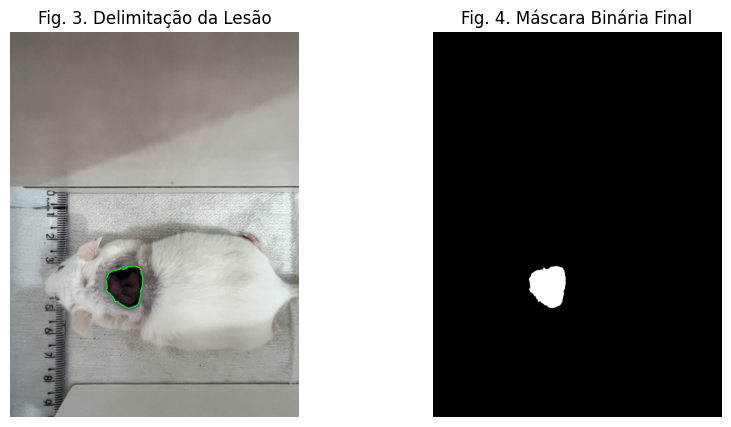

Área Final Refinada: 4.72 cm²


In [10]:
# Encontrar contornos na máscara
contours, _ = cv2.findContours(opening, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Selecionar apenas o maior contorno (evita pegar ruídos da régua)
if contours:
    maior_contorno = max(contours, key=cv2.contourArea)

    # Criar máscara limpa apenas com a ferida
    mask_final = np.zeros_like(opening)
    cv2.drawContours(mask_final, [maior_contorno], -1, 255, -1)

    # Desenhar o contorno na imagem original para o relatório
    img_contorno = img_rgb.copy()
    cv2.drawContours(img_contorno, [maior_contorno], -1, (0, 255, 0), 10)

    # Recalcular área precisa
    area_pixels_fina = cv2.contourArea(maior_contorno)
    area_cm2_fina = area_pixels_fina / (pixels_por_cm**2)

# Exibição Final para o Relatório
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_contorno)
plt.title('Fig. 3. Delimitação da Lesão') # Seguindo
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_final, cmap='gray')
plt.title('Fig. 4. Máscara Binária Final') # Seguindo
plt.axis('off')
plt.show()

print(f"Área Final Refinada: {area_cm2_fina:.2f} cm²") # Seguindo [cite: 36]

In [12]:
# Exemplo de download de dataset via terminal no Colab
!git clone https://github.com/uwm-cv/wound-segmentation.git

Cloning into 'wound-segmentation'...
fatal: could not read Username for 'https://github.com': No such device or address
